In [18]:
# In this notebook I want to run the RL trading agent and
# visualize how good or bad it trades based on sentiment.
# I import the RL functions from rl_trader.py.
# I also add the parent folder to the path so python can find my files.

import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ensure project root is visible
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

# importing Q-learning trainer and strategy runner
from rl_trader import train_q_learning, run_strategy


In [19]:
# In this cell I am loading the merged dataset that we created earlier.
# This file already has sentiment scores + stock prices for each timestamp.
# RL training needs both, so this is the dataset I will use.

merged_df = pd.read_csv("../merged_news_stock_sentiment.csv")

# Just checking the first few rows to make sure everything looks fine
merged_df.head()


,title,description,publishedAt,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits,sentiment
0,Earnings live: Zoom stock pops after upbeat re...,The third quarter earnings season has been mos...,2025-11-24 21:30:15+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,-0.0258
1,Stocks Finish Sharply Higher as Tech Stocks Soar,The S&P 500 Index ($SPX ) (SPY ) on Monday clo...,2025-11-24 21:35:37+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,0.0000
2,Apple shares hit new all-time closing high,"In Nasdaq trading today, shares of Apple Inc. ...",2025-11-24 21:41:03+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,0.2960
3,Cuts Jobs in Sales Division,NaN,2025-11-25 07:15:11+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0,-0.2960
4,Is Apple Stock Outperforming the Dow?,Apple stock has outperformed the Dow Jones ove...,2025-11-25 10:23:02+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0,0.0000


In [20]:
# In this cell I'm importing the Q-learning functions that we wrote in rl_trader.py.
# These include:
# 1. train_q_learning() → actually trains the RL agent
# 2. run_strategy() → runs the trained agent on the dataset

from rl_trader import train_q_learning, run_strategy

# Now I train the Q-learning agent.
# I'm using 200 episodes (kind of like 200 practice runs for the agent).
# The output will be a Q-table that stores the learned trading decisions.

Q_table = train_q_learning(merged_df, episodes=200)

# Just printing the shape to confirm training happened
Q_table.shape


(15, 3)

In [21]:
# Fix: Make sure Datetime column is actually a datetime type
merged_df["Datetime"] = pd.to_datetime(merged_df["Datetime"], utc=True)

merged_df.head()


,title,description,publishedAt,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits,sentiment
0,Earnings live: Zoom stock pops after upbeat re...,The third quarter earnings season has been mos...,2025-11-24 21:30:15+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,-0.0258
1,Stocks Finish Sharply Higher as Tech Stocks Soar,The S&P 500 Index ($SPX ) (SPY ) on Monday clo...,2025-11-24 21:35:37+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,0.0000
2,Apple shares hit new all-time closing high,"In Nasdaq trading today, shares of Apple Inc. ...",2025-11-24 21:41:03+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,0.2960
3,Cuts Jobs in Sales Division,NaN,2025-11-25 07:15:11+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0,-0.2960
4,Is Apple Stock Outperforming the Dow?,Apple stock has outperformed the Dow Jones ove...,2025-11-25 10:23:02+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0,0.0000


In [26]:
# Now I am running the RL strategy on the merged dataset.
# The agent uses the Q-table we trained earlier to decide whether to go
# long, short, or stay flat at each time step.

#wandb is disabled as we are already doing it in the .py version (rl_trader.py)
import wandb
wandb.init(mode="disabled")


strategy_df, stats = run_strategy(merged_df, Q_table)

# I want to see the first few rows to check if everything is aligned.
strategy_df.head()



      RL PERFORMANCE SUMMARY
Total Trades:           30
Long Trades:            10
Short Trades:           6
Win Rate:               37.50%
Final Return:           3.36%
Max Drawdown:           -0.44%
Sharpe Ratio:           3.773
Start Equity:           1.0000
End Equity:             1.0336



,title,description,publishedAt,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits,sentiment,capital,position
0,Stocks Finish Sharply Higher as Tech Stocks Soar,The S&P 500 Index ($SPX ) (SPY ) on Monday clo...,2025-11-24 21:35:37+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,0.000,1.000000,0
1,Apple shares hit new all-time closing high,"In Nasdaq trading today, shares of Apple Inc. ...",2025-11-24 21:41:03+00:00,2025-11-24 20:30:00+00:00,276.470001,276.980011,275.109985,275.980011,4904039,0.0,0.0,0.296,1.000000,0
2,Cuts Jobs in Sales Division,NaN,2025-11-25 07:15:11+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0,-0.296,1.010599,1
3,Is Apple Stock Outperforming the Dow?,Apple stock has outperformed the Dow Jones ove...,2025-11-25 10:23:02+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0,0.000,1.010599,-1
4,"Earnings live: Kohl's, Abercrombie stocks soar...",The third quarter earnings season has been mos...,2025-11-25 13:15:54+00:00,2025-11-25 14:30:00+00:00,275.299988,280.380005,275.269989,278.904999,9723608,0.0,0.0,0.000,1.010599,0


In [27]:
# Here I am just printing the performance statistics we collected earlier.

import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": [
        "Final Return (%)",
        "Win Rate (%)",
        "Sharpe Ratio",
        "Max Drawdown (%)",
        "Total Trades",
        "Long Trades",
        "Short Trades"
    ],
    "Value": [
        round(stats["Final_Return"], 2),
        round(stats["Win_Rate"], 2),
        round(stats["Sharpe_Ratio"], 3),
        round(stats["Max_Drawdown"], 2),
        stats["Total_Trades"],
        stats["Long_Trades"],
        stats["Short_Trades"]
    ]
})

metrics_df

,Metric,Value
0,Final Return (%),3.360
1,Win Rate (%),37.500
2,Sharpe Ratio,3.773
3,Max Drawdown (%),-0.440
4,Total Trades,30.000
5,Long Trades,10.000
6,Short Trades,6.000


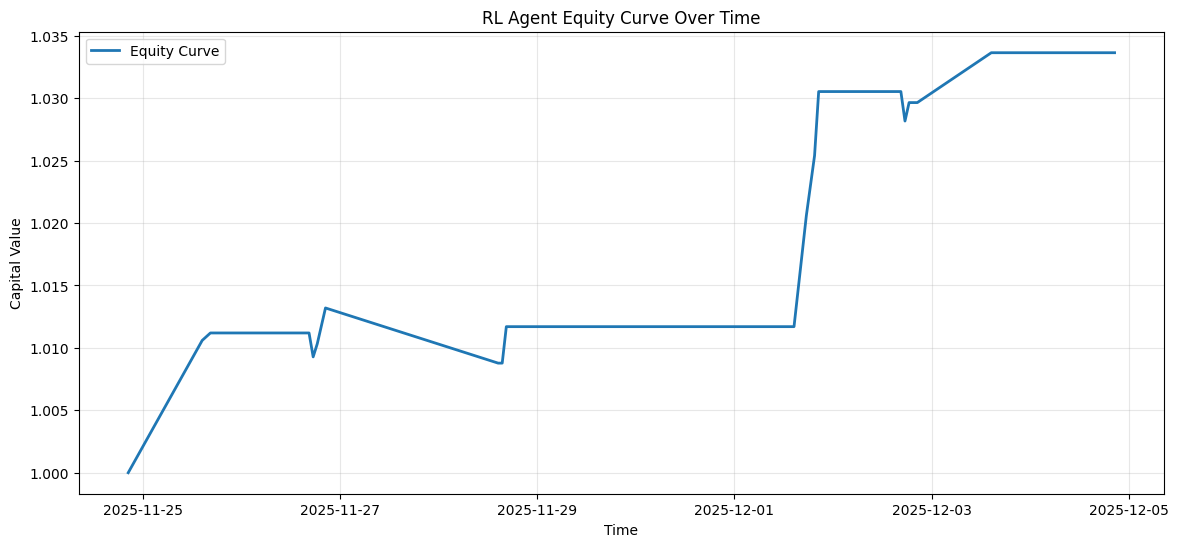

In [28]:
# In this cell I'm plotting the equity curve produced by the RL agent.
# This shows how the capital grows (or falls) over time based on the agent's decisions.
# I am also showing the positions (long/short/flat) to see how the agent behaves.

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot the equity curve
plt.plot(strategy_df["Datetime"], strategy_df["capital"], label="Equity Curve", linewidth=2)

plt.title("RL Agent Equity Curve Over Time")
plt.xlabel("Time")
plt.ylabel("Capital Value")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


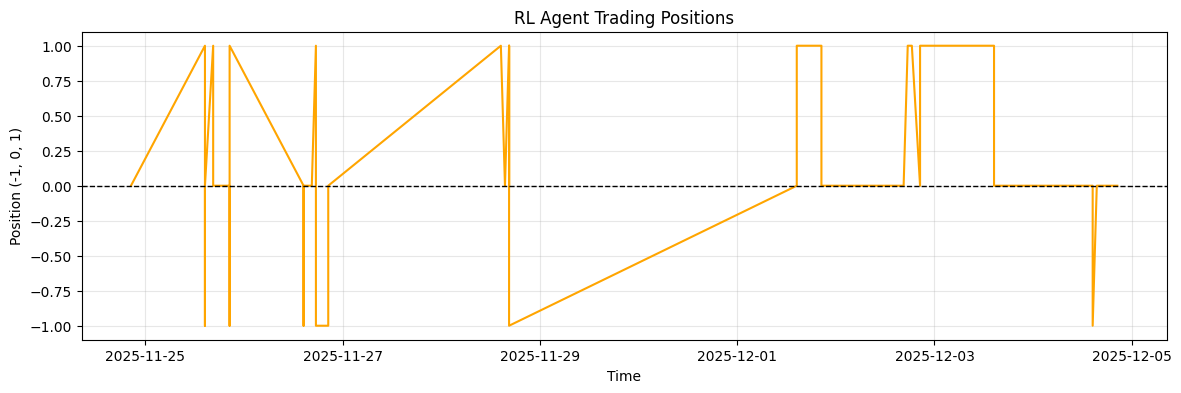

In [29]:
# Now I want to visualize the position taken by the RL agent over time.
# - 1 means long
# - -1 means short
# - 0 means flat (no trade)

plt.figure(figsize=(14, 4))

plt.plot(strategy_df["Datetime"], strategy_df["position"], label="Position", color="orange")
plt.axhline(0, color="black", linewidth=1, linestyle="--")

plt.title("RL Agent Trading Positions")
plt.xlabel("Time")
plt.ylabel("Position (-1, 0, 1)")
plt.grid(alpha=0.3)
plt.show()


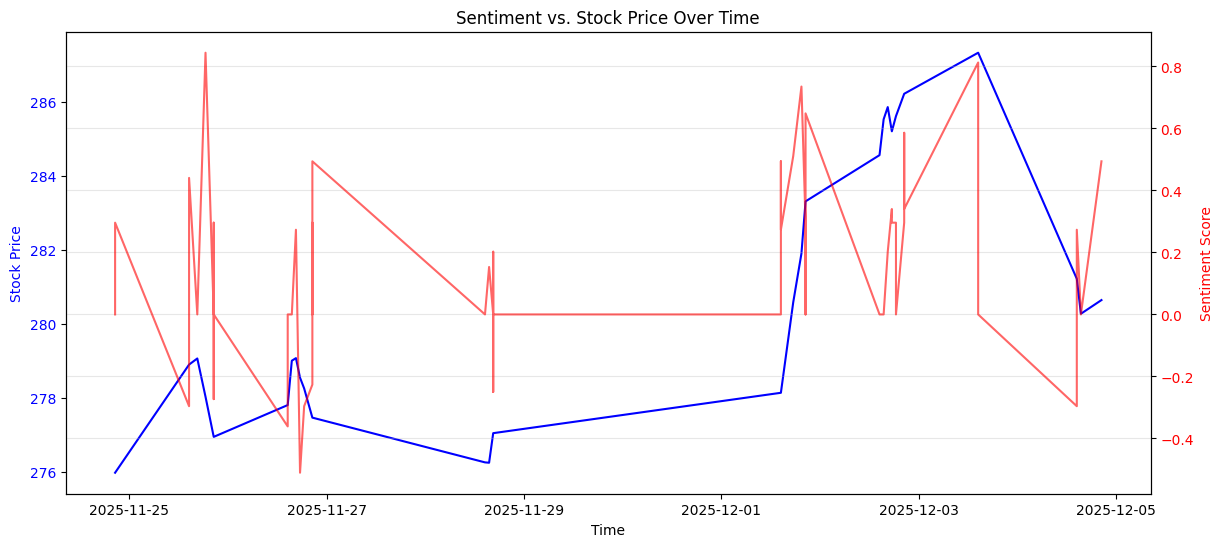

In [30]:
# In this cell I want to see how sentiment scores move compared to the stock price.
# This helps me explain the intuition behind the model:
# positive news sentiment should ideally match with price going up,
# and negative sentiment should match with price going down.

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot stock price
ax1.plot(strategy_df["Datetime"], strategy_df["Close"], label="Stock Price", color="blue")
ax1.set_xlabel("Time")
ax1.set_ylabel("Stock Price", color="blue")
ax1.tick_params(axis='y', labelcolor='blue')

# Create second axis for sentiment
ax2 = ax1.twinx()
ax2.plot(strategy_df["Datetime"], strategy_df["sentiment"], label="Sentiment Score", color="red", alpha=0.6)
ax2.set_ylabel("Sentiment Score", color="red")
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Sentiment vs. Stock Price Over Time")
plt.grid(alpha=0.3)
plt.show()


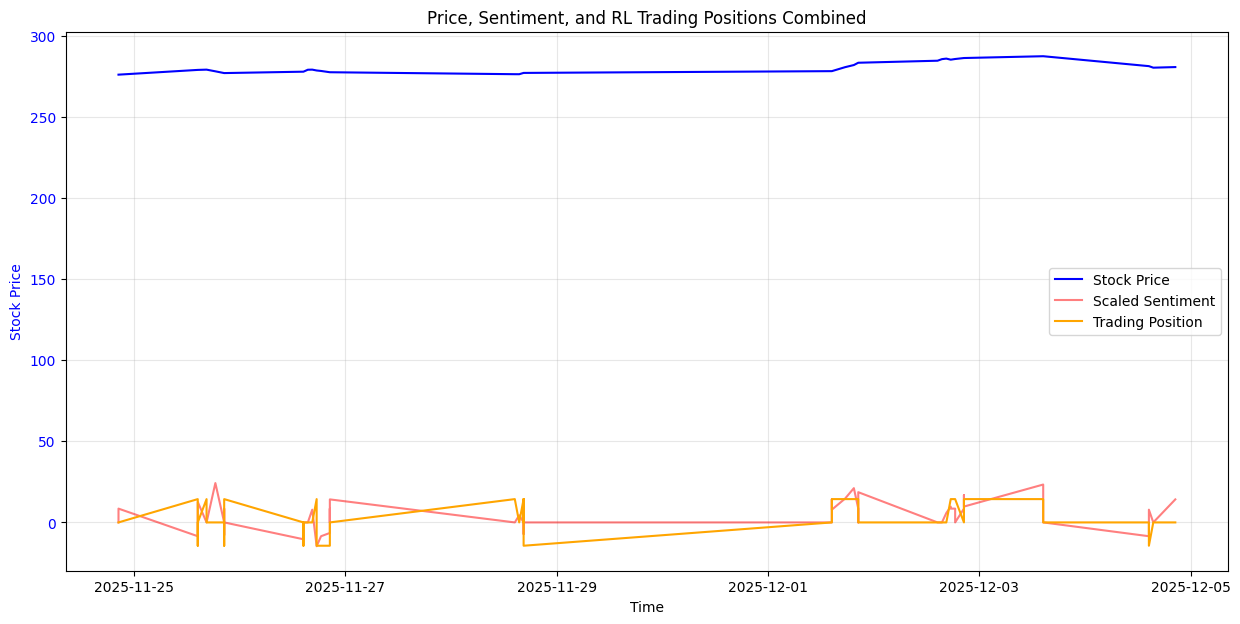

In [31]:
# In this cell I am combining everything together:
# - stock price (main plot)
# - sentiment score (scaled so it fits visually)
# - RL agent positions (-1, 0, 1)
# This plot helps show how the trading decisions relate to both price and sentiment.

fig, ax1 = plt.subplots(figsize=(15, 7))

# Stock Price (left axis) 
ax1.plot(strategy_df["Datetime"], strategy_df["Close"], label="Stock Price", color="blue")
ax1.set_xlabel("Time")
ax1.set_ylabel("Stock Price", color="blue")
ax1.tick_params(axis='y', labelcolor='blue')

# Sentiment (scaled, right axis) 
sent_scaled = strategy_df["sentiment"] * strategy_df["Close"].max() * 0.1
ax1.plot(strategy_df["Datetime"], sent_scaled, label="Scaled Sentiment", color="red", alpha=0.5)

# RL Positions 
pos_scaled = strategy_df["position"] * strategy_df["Close"].max() * 0.05
ax1.plot(strategy_df["Datetime"], pos_scaled, label="Trading Position", color="orange")

plt.title("Price, Sentiment, and RL Trading Positions Combined")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
